In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from tqdm import tqdm

import importlib

import global_mapping as gm
import w1_tree as wt
import representation_metrics as rm 
import scipy.spatial.distance as spd

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches


PATH = "../data_clean/"


In [128]:
df_country = pd.read_csv("../data/Floriana_country_info.csv")
df_topics = pd.read_csv("../data_clean/df_topics.csv")
df_topics.subfield_id = df_topics.subfield_id.astype(int)

df_cs = pd.read_csv(PATH+"df_country_subfield_roll_5y.csv", index_col=[0, 1, 2]).dropna(how="all")
df_cs.columns = df_cs.columns.astype(int)

year_list = df_cs.index.get_level_values(1).unique().sort_values().to_list()
country_list = df_cs.index.get_level_values(0).unique().sort_values().to_list()

df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

df_total = (
    df_cs
    .sum(axis=1)
    .to_frame("total")
    .reset_index()
    .pivot(index=["country", "year"], columns=["mode"])
    .xs("total", axis=1)
    .assign(collab_share = lambda df: df.collaborative / (df.collaborative + df.individual))
)

df_dist = pd.read_csv(PATH+"df_dist_country.csv", index_col=[0, 1, 2])

In [129]:
weight_base=10.0

In [130]:
# df_subfield_full = (
#     pd.read_csv(PATH+"df_topics.csv")
#     [["subfield_id", "subfield_name", "field_id", "field_name", "domain_id", "domain_name"]]
#     .drop_duplicates()
#     .sort_values(["domain_id", "field_id", "subfield_id"])
# )
# df_subfield.subfield_id = df_subfield.subfield_id.astype(int)

df_subfield = (
    pd.read_csv(PATH+"df_topics.csv")
    [["subfield_id", "subfield_name", "field_id", "field_name", "domain_id", "domain_name"]]
    .drop_duplicates()
    .sort_values(["domain_id", "field_id", "subfield_id"])
)
df_subfield.subfield_id = df_subfield.subfield_id.astype(int)

w1_tree = wt.W1Tree(df_subfield[["domain_id", "field_id", "subfield_id"]], weight_base=weight_base)

In [131]:
year = 2023
country = "RU"

In [132]:
df = df_prob.xs(year, level=(1))

In [133]:
df_dist = w1_tree.dist(df.xs("individual", level=1), df.xs("collaborative", level=1))

In [134]:
df_indiv = df.xs("individual", level=1)
df_collab = df.xs("collaborative", level=1)

cosine_list = []
index_list = []
for c in df_indiv.index:
    if c not in df_collab.index:
        continue
    else:    
        cosine_list.append(spd.cosine(df_indiv.loc[c].fillna(0), df_collab.loc[c].fillna(0)))
        index_list.append(c)

In [135]:
df_stat = (
    pd.DataFrame(cosine_list, index=index_list, columns=["cosine"])
    .assign(w1_tree=np.diagonal(df_dist.loc[index_list, index_list]))
)

In [136]:
df_stat

,cosine,w1_tree
AE,0.085884,0.103843
AF,0.530219,0.369344
AG,0.776019,0.255881
AL,0.390374,0.336965
AM,0.359837,0.292440
...,...,...
WS,1.000000,0.603604
YE,0.230882,0.233069
ZA,0.227034,0.220741
ZM,0.379698,0.378581


In [137]:
px.box(df_stat)

In [138]:
df_stat_full = (
    df_total.xs(year, level=1)
    .merge(df_stat, left_index=True, right_index=True, how="right")
    .query("(individual >= 500) and (collaborative >= 500)")
    .assign(
        log_individual=lambda df: np.log(df.individual),
        log_collaborative=lambda df: np.log(df.collaborative),
    )
)

In [139]:
df_stat_full.corr()

,collaborative,individual,collab_share,cosine,w1_tree,log_individual,log_collaborative
collaborative,1.000000,0.901862,-0.160033,-0.260347,-0.282732,0.606463,0.637173
individual,0.901862,1.000000,-0.312169,-0.221134,-0.250570,0.562840,0.518036
collab_share,-0.160033,-0.312169,1.000000,0.062158,0.120321,-0.523976,-0.210017
cosine,-0.260347,-0.221134,0.062158,1.000000,0.906770,-0.534962,-0.604489
w1_tree,-0.282732,-0.250570,0.120321,0.906770,1.000000,-0.515449,-0.558536
log_individual,0.606463,0.562840,-0.523976,-0.534962,-0.515449,1.000000,0.940790
log_collaborative,0.637173,0.518036,-0.210017,-0.604489,-0.558536,0.940790,1.000000


In [140]:
metric = ["w1_tree", "cosine"]
px.bar(df_stat_full.sort_values(metric).reset_index(), x=df_stat_full.sort_values(metric).index, y=metric, barmode="group")

In [141]:
df_stat_full.sort_values(metric)

,collaborative,individual,collab_share,cosine,w1_tree,log_individual,log_collaborative
VG,839.0,763.0,0.523720,0.006309,0.006913,6.637258,6.732211
BD,28575.0,44569.0,0.390668,0.041413,0.040007,10.704794,10.260287
CN,800008.0,3030783.0,0.208836,0.024528,0.065292,14.924332,13.592377
IN,209282.0,1006887.0,0.172083,0.042969,0.076649,13.822374,12.251438
TH,39456.0,69560.0,0.361929,0.062683,0.084011,11.149945,10.582941
...,...,...,...,...,...,...,...
MU,548.0,788.0,0.410180,0.583283,0.460282,6.669498,6.306275
SS,1928.0,1400.0,0.579327,0.421791,0.516519,7.244228,7.564238
PA,2409.0,47536.0,0.048233,0.815786,0.539132,10.769243,7.786967
BI,785.0,762.0,0.507434,0.523247,0.593031,6.635947,6.665684


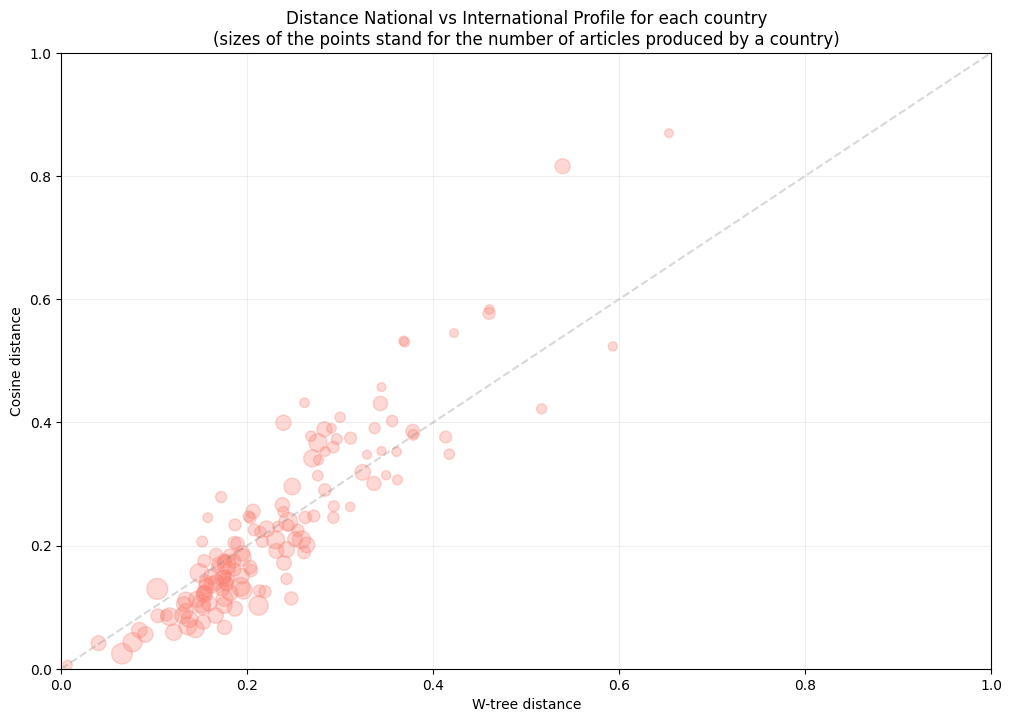

In [142]:
x = df_stat_full.w1_tree
y = df_stat_full.cosine
s = df_stat_full.log_individual

plt.subplots(figsize=(12, 8))
plt.scatter(x, y, s=1*(s**2), alpha=0.3, color="salmon")
plt.plot(np.linspace(0, 1, 100), np.linspace(0, 1, 100), color="grey", linestyle="--", alpha=0.3)
plt.xlabel("W-tree distance")
plt.ylabel("Cosine distance")
plt.ylim(0, 1)
plt.xlim(0, 1)
plt.title("Distance National vs International Profile for each country\n(sizes of the points stand for the number of articles produced by a country)")
plt.grid(alpha=0.2)

In [143]:
# px.scatter(df_stat_full, x="log_individual", y="w1_tree", hover_name=df_stat_full.index)

In [144]:
# px.scatter(df_stat_full, x="log_individual", y="cosine")

In [145]:
importlib.reload(wt)

<module 'w1_tree' from '/Users/irinavorobeva/Sociology/Geography Topics/geoTopics/irina_clean/w1_tree.py'>

In [146]:
w1_tree = wt.W1Tree(df_subfield[["domain_id", "field_id", "subfield_id"]], weight_base=weight_base)

c = "BJ"

df_c = df_prob.loc[c].xs(2023)
df_dist = w1_tree.dist(df_c.loc["individual"].to_frame("individual").T,
                       df_c.loc["collaborative"].to_frame("collaborative").T)
df_dist

second,collaborative
first,
individual,0.176256


In [147]:
spd.cosine(df_c.loc["individual"].fillna(0), df_c.loc["collaborative"].fillna(0))

np.float64(0.17643172776212224)

In [148]:
# df_subfield = df_topics[["subfield_id", "field_id", "domain_id"]].drop_duplicates().sort_values(["domain_id", "field_id", "subfield_id"])
# df_subfield.subfield_id = df_subfield.subfield_id.astype(int)
sf_ordered = df_subfield.subfield_id.to_list()
domain_list = df_subfield.domain_id.drop_duplicates().to_list()
field_list = df_subfield.field_id.drop_duplicates().to_list()
domain_name_list = df_topics[["subfield_id", "field_id", "domain_id", "domain_name"]].drop_duplicates().sort_values(["domain_id", "field_id", "subfield_id"]).domain_name.drop_duplicates().to_list()

In [149]:
df_stat_full.loc[c].to_frame(c).T

,collaborative,individual,collab_share,cosine,w1_tree,log_individual,log_collaborative
BJ,2276.0,2337.0,0.493388,0.176432,0.176256,7.756623,7.730175


In [150]:
df_subfield[["subfield_id", "domain_id"]].subfield_id

1597    1100
341     1102
156     1103
269     1104
7       1105
        ... 
2398    3609
1434    3611
525     3612
865     3614
1361    3616
Name: subfield_id, Length: 252, dtype: int64

In [151]:
(
        df_indiv_c.to_frame("individual")
        .merge(df_subfield[["subfield_id", "domain_id"]], left_index=True, right_on="subfield_id")
        .drop(columns="subfield_id")
        .query("domain_id == @domain")
        .individual
        .sum()
    )

np.float64(0.20992646981827928)

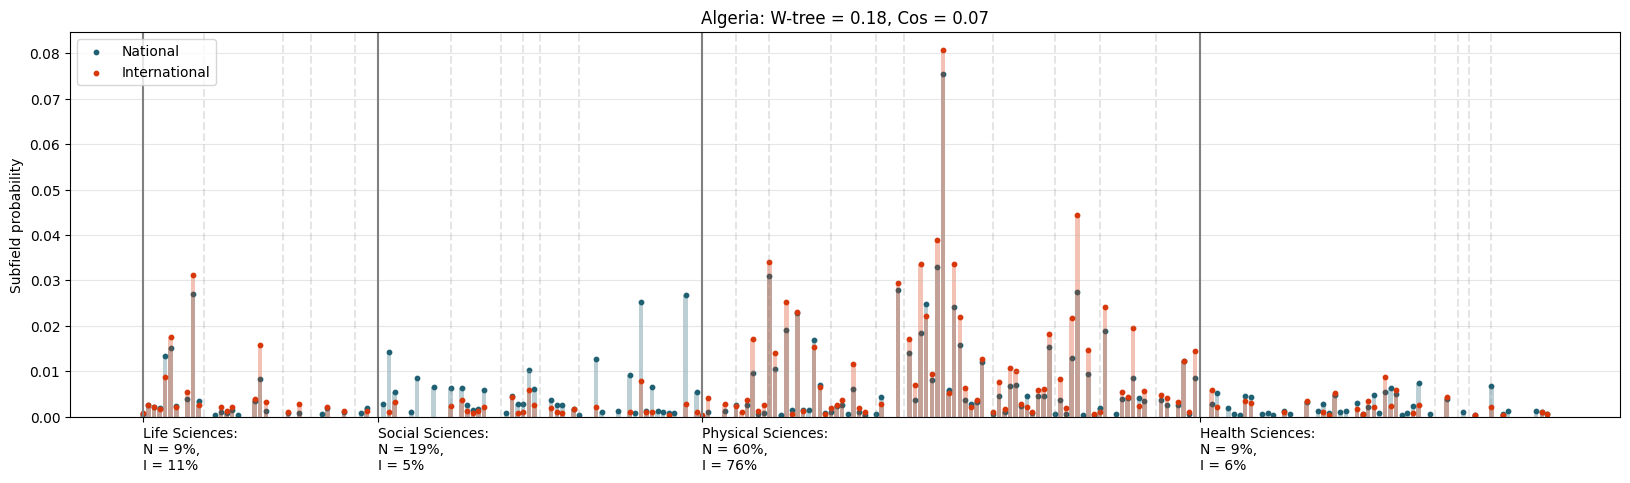

In [152]:
c = "DZ"
c1 = "National"
c2 = "International"

df_indiv_c = df_prob.xs((year, "individual"), level=(1, 2))[sf_ordered].loc[c]
df_collab_c = df_prob.xs((year, "collaborative"), level=(1, 2))[sf_ordered].loc[c]

# c1 = "CH"
# c2 = "BE"

# df_indiv_c = df_prob.xs((year, "individual"), level=(1, 2))[sf_ordered].loc[c1]
# df_collab_c = df_prob.xs((year, "individual"), level=(1, 2))[sf_ordered].loc[c2]

fig, ax = plt.subplots(figsize = (20, 5))
ax.bar(df_indiv_c.index.astype(str), df_indiv_c.values, color="#1F6173", alpha=0.3)
ax.scatter(df_indiv_c.index.astype(str), df_indiv_c.values, s=10, color="#1F6173", label=c1)

ax.bar(df_collab_c.index.astype(str), df_collab_c.values, color="#D8370A", alpha=0.3)
ax.scatter(df_collab_c.index.astype(str), df_collab_c.values, s=10, color="#D8370A", label=c2)

x_ticks = []
x_ticks_labels = []

for i, domain in enumerate(domain_list):
    start_domain = df_subfield.query("domain_id == @domain").subfield_id.iloc[0].astype(str)
    n_share = int((
        df_indiv_c.to_frame("individual")
        .merge(df_subfield[["subfield_id", "domain_id"]], left_index=True, right_on="subfield_id")
        .drop(columns="subfield_id")
        .query("domain_id == @domain")
        .individual
        .sum()
    ) * 100)
    i_share = int((
        df_collab_c.to_frame("collaborative")
        .merge(df_subfield[["subfield_id", "domain_id"]], left_index=True, right_on="subfield_id")
        .drop(columns="subfield_id")
        .query("domain_id == @domain")
        .collaborative
        .sum()
    ) * 100)
    ax.axvline(start_domain, color="grey")
    x_ticks.append(start_domain)
    x_ticks_labels.append(domain_name_list[i]+f":\nN = {n_share}%,\nI = {i_share}%")

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontdict={"horizontalalignment": "left"})

for field in field_list:
    start_domain = df_subfield.query("field_id == @field").subfield_id.iloc[0].astype(str)
    ax.axvline(start_domain, color="grey", linestyle="--", alpha=0.2)

plt.legend()
# ax.axvline("1110", color="red")

ax.grid(axis="y", alpha=0.3)
# ax.set_ylim(0, 0.05)
# _ = ax.set_xticks([],labels=[])
wt_dist = np.round(w1_tree.dist(df_indiv_c.to_frame(c1).T, df_collab_c.to_frame(c2).T).iloc[0, 0], 2)
cos_dist = np.round(spd.cosine(df_indiv_c.fillna(0), df_collab_c.fillna(0)), 2)

c_name = df_country[df_country["alpha-2"] == c].name.iloc[0]
_ = ax.set_title(f"{c_name}: W-tree = {wt_dist}, Cos = {cos_dist}")
_ = ax.set_ylabel("Subfield probability")
# fig.savefig(
#     "profiles.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight"
# )

In [153]:
df_country

,name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
0,Afghanistan,AF,AFG,4,ISO 3166-2:AF,Asia,Southern Asia,NaN,142.0,34.0,NaN
1,Åland Islands,AX,ALA,248,ISO 3166-2:AX,Europe,Northern Europe,NaN,150.0,154.0,NaN
2,Albania,AL,ALB,8,ISO 3166-2:AL,Europe,Southern Europe,NaN,150.0,39.0,NaN
3,Algeria,DZ,DZA,12,ISO 3166-2:DZ,Africa,Northern Africa,NaN,2.0,15.0,NaN
4,American Samoa,AS,ASM,16,ISO 3166-2:AS,Oceania,Polynesia,NaN,9.0,61.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
244,Wallis and Futuna,WF,WLF,876,ISO 3166-2:WF,Oceania,Polynesia,NaN,9.0,61.0,NaN
245,Western Sahara,EH,ESH,732,ISO 3166-2:EH,Africa,Northern Africa,NaN,2.0,15.0,NaN
246,Yemen,YE,YEM,887,ISO 3166-2:YE,Asia,Western Asia,NaN,142.0,145.0,NaN
247,Zambia,ZM,ZMB,894,ISO 3166-2:ZM,Africa,Sub-Saharan Africa,Eastern Africa,2.0,202.0,14.0


In [154]:
df_subfield

,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
1597,1100,General Agricultural and Biological Sciences,11,Agricultural and Biological Sciences,1,Life Sciences
341,1102,Agronomy and Crop Science,11,Agricultural and Biological Sciences,1,Life Sciences
156,1103,Animal Science and Zoology,11,Agricultural and Biological Sciences,1,Life Sciences
269,1104,Aquatic Science,11,Agricultural and Biological Sciences,1,Life Sciences
7,1105,"Ecology, Evolution, Behavior and Systematics",11,Agricultural and Biological Sciences,1,Life Sciences
...,...,...,...,...,...,...
2398,3609,Occupational Therapy,36,Health Professions,4,Health Sciences
1434,3611,Pharmacy,36,Health Professions,4,Health Sciences
525,3612,"Physical Therapy, Sports Therapy and Rehabilit...",36,Health Professions,4,Health Sciences
865,3614,Radiological and Ultrasound Technology,36,Health Professions,4,Health Sciences


In [155]:
field_dict = {
    "Environmental Science": "Environ. Sc.",
    "Physics and Astronomy": "Phys. & Astron.",
    "Earth and Planetary Sciences": "Earth & Planet.",
    "Economics, Econometrics and Finance": "Econ. & Finance                  ",
    "Pharmacology, Toxicology and Pharmaceutics": "        Pharma. & Toxicology",
    "Veterinary": "Veterinary                 ",
    "Business, Management and Accounting": "Business & Account.",
    "Immunology and Microbiology": "Immun. & Microbio.",
    "Biochemistry, Genetics and Molecular Biology": "Biochem. & Genetics",
    "Arts and Humanities": "Arts & Humanities",
    "Agricultural and Biological Sciences": "Agricult. & Bio. Sc.",
    "Dentistry": "   Dentistry",
    "Nursing": "  Nursing"
}

In [156]:
df_subfield

,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
1597,1100,General Agricultural and Biological Sciences,11,Agricultural and Biological Sciences,1,Life Sciences
341,1102,Agronomy and Crop Science,11,Agricultural and Biological Sciences,1,Life Sciences
156,1103,Animal Science and Zoology,11,Agricultural and Biological Sciences,1,Life Sciences
269,1104,Aquatic Science,11,Agricultural and Biological Sciences,1,Life Sciences
7,1105,"Ecology, Evolution, Behavior and Systematics",11,Agricultural and Biological Sciences,1,Life Sciences
...,...,...,...,...,...,...
2398,3609,Occupational Therapy,36,Health Professions,4,Health Sciences
1434,3611,Pharmacy,36,Health Professions,4,Health Sciences
525,3612,"Physical Therapy, Sports Therapy and Rehabilit...",36,Health Professions,4,Health Sciences
865,3614,Radiological and Ultrasound Technology,36,Health Professions,4,Health Sciences


In [157]:
df_country

,name,alpha-2,alpha-3,country-code,iso_3166-2,region,sub-region,intermediate-region,region-code,sub-region-code,intermediate-region-code
0,Afghanistan,AF,AFG,4,ISO 3166-2:AF,Asia,Southern Asia,NaN,142.0,34.0,NaN
1,Åland Islands,AX,ALA,248,ISO 3166-2:AX,Europe,Northern Europe,NaN,150.0,154.0,NaN
2,Albania,AL,ALB,8,ISO 3166-2:AL,Europe,Southern Europe,NaN,150.0,39.0,NaN
3,Algeria,DZ,DZA,12,ISO 3166-2:DZ,Africa,Northern Africa,NaN,2.0,15.0,NaN
4,American Samoa,AS,ASM,16,ISO 3166-2:AS,Oceania,Polynesia,NaN,9.0,61.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
244,Wallis and Futuna,WF,WLF,876,ISO 3166-2:WF,Oceania,Polynesia,NaN,9.0,61.0,NaN
245,Western Sahara,EH,ESH,732,ISO 3166-2:EH,Africa,Northern Africa,NaN,2.0,15.0,NaN
246,Yemen,YE,YEM,887,ISO 3166-2:YE,Asia,Western Asia,NaN,142.0,145.0,NaN
247,Zambia,ZM,ZMB,894,ISO 3166-2:ZM,Africa,Sub-Saharan Africa,Eastern Africa,2.0,202.0,14.0


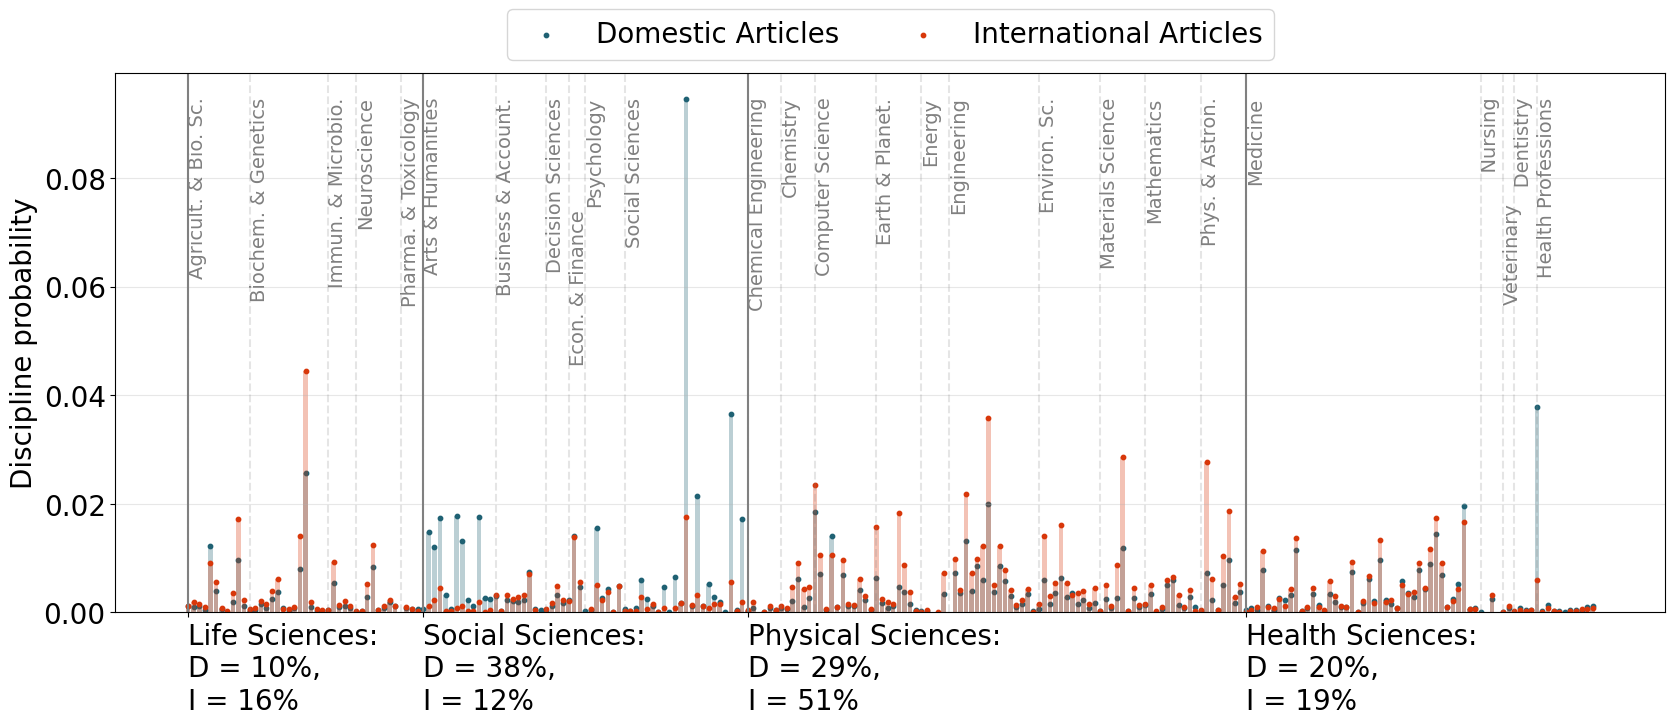

In [162]:
c = "FR"
c1 = "Domestic Articles"
c2 = "International Articles"

df_indiv_c = df_prob.xs((year, "individual"), level=(1, 2))[sf_ordered].loc[c]
df_collab_c = df_prob.xs((year, "collaborative"), level=(1, 2))[sf_ordered].loc[c]

# c1 = "CH"
# c2 = "BE"

# df_indiv_c = df_prob.xs((year, "individual"), level=(1, 2))[sf_ordered].loc[c1]
# df_collab_c = df_prob.xs((year, "individual"), level=(1, 2))[sf_ordered].loc[c2]

fig, ax = plt.subplots(figsize = (20, 7))
ax.bar(df_indiv_c.index.astype(str), df_indiv_c.values, color="#1F6173", alpha=0.3)
ax.scatter(df_indiv_c.index.astype(str), df_indiv_c.values, s=10, color="#1F6173", label=c1)

ax.bar(df_collab_c.index.astype(str), df_collab_c.values, color="#D8370A", alpha=0.3)
ax.scatter(df_collab_c.index.astype(str), df_collab_c.values, s=10, color="#D8370A", label=c2)

x_ticks = []
x_ticks_labels = []

for i, domain in enumerate(domain_list):
    start_domain = df_subfield.query("domain_id == @domain").subfield_id.iloc[0].astype(str)
    n_share = int((
        df_indiv_c.to_frame("individual")
        .merge(df_subfield[["subfield_id", "domain_id"]], left_index=True, right_on="subfield_id")
        .drop(columns="subfield_id")
        .query("domain_id == @domain")
        .individual
        .sum()
    ) * 100)
    i_share = int((
        df_collab_c.to_frame("collaborative")
        .merge(df_subfield[["subfield_id", "domain_id"]], left_index=True, right_on="subfield_id")
        .drop(columns="subfield_id")
        .query("domain_id == @domain")
        .collaborative
        .sum()
    ) * 100)
    ax.axvline(start_domain, color="grey")
    x_ticks.append(start_domain)
    x_ticks_labels.append(domain_name_list[i]+f":\nD = {n_share}%,\nI = {i_share}%")
    # x_ticks_labels.append(domain_name_list[i])

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontdict={"horizontalalignment": "left"}, fontsize=20)
ax.tick_params(axis='y', labelsize=20)

for field in field_list:
    field_name = df_subfield[df_subfield["field_id"] == field].field_name.iloc[0]
    if field_name in field_dict.keys():
        field_name = field_dict[field_name]
    start_domain = df_subfield.query("field_id == @field").subfield_id.iloc[0].astype(str)
    ax.axvline(start_domain, color="grey", linestyle="--", alpha=0.2)
    ax.text(x=start_domain, y=0.095, s=field_name, color="grey", rotation=90, va="top", fontsize=14)

plt.legend(fontsize=20, loc="lower center", bbox_to_anchor=(0.5, 1), ncols=2)
# ax.axvline("1110", color="red")

ax.grid(axis="y", alpha=0.3)
# ax.set_ylim(0, 0.05)
# _ = ax.set_xticks([],labels=[])
wt_dist = np.round(w1_tree.dist(df_indiv_c.to_frame(c1).T, df_collab_c.to_frame(c2).T).iloc[0, 0], 2)
cos_dist = np.round(spd.cosine(df_indiv_c.fillna(0), df_collab_c.fillna(0)), 2)

c_name = df_country[df_country["alpha-2"] == c].name.iloc[0]

# _ = ax.set_title(r"France: $W_1^{\mathcal{T}}$ = "+f"{wt_dist}", fontsize=)
_ = ax.set_ylabel("Discipline probability", fontsize=20)
# fig.savefig(
#     "profiles.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight"
# )
plt.savefig(f"../france_probabilities_v1.jpg", dpi=1000, bbox_inches='tight')

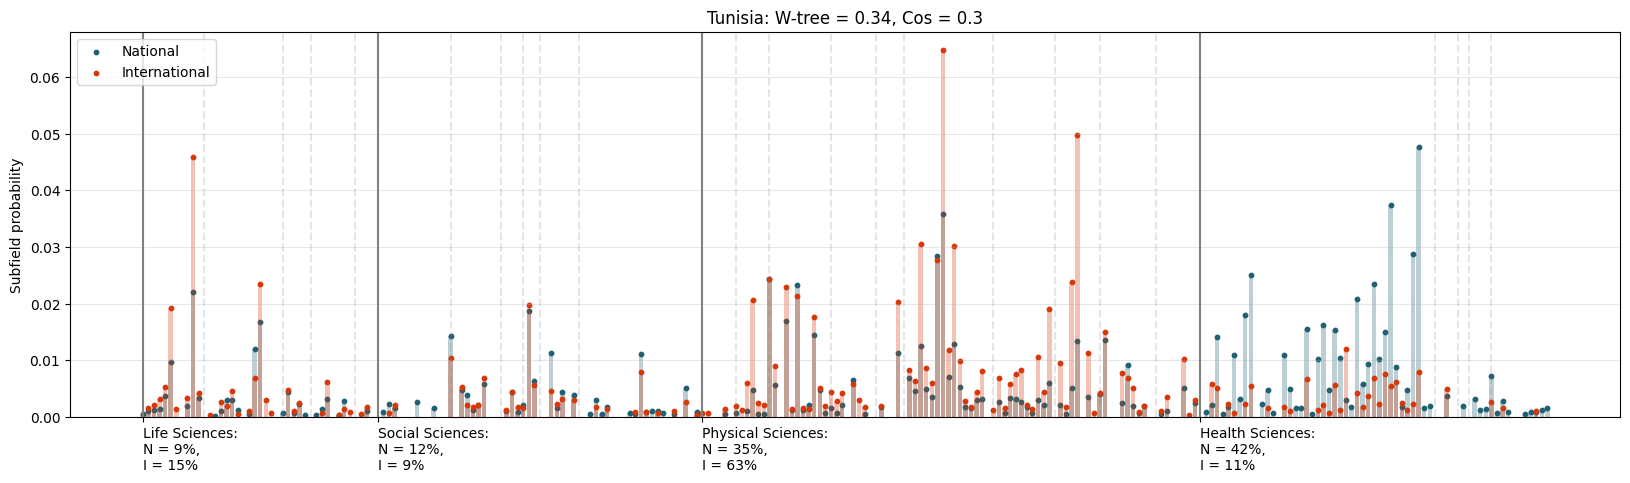

In [159]:
c = "TN"
c1 = "National"
c2 = "International"

df_indiv_c = df_prob.xs((year, "individual"), level=(1, 2))[sf_ordered].loc[c]
df_collab_c = df_prob.xs((year, "collaborative"), level=(1, 2))[sf_ordered].loc[c]

# c1 = "CH"
# c2 = "BE"

# df_indiv_c = df_prob.xs((year, "individual"), level=(1, 2))[sf_ordered].loc[c1]
# df_collab_c = df_prob.xs((year, "individual"), level=(1, 2))[sf_ordered].loc[c2]

fig, ax = plt.subplots(figsize = (20, 5))
ax.bar(df_indiv_c.index.astype(str), df_indiv_c.values, color="#1F6173", alpha=0.3)
ax.scatter(df_indiv_c.index.astype(str), df_indiv_c.values, s=10, color="#1F6173", label=c1)

ax.bar(df_collab_c.index.astype(str), df_collab_c.values, color="#D8370A", alpha=0.3)
ax.scatter(df_collab_c.index.astype(str), df_collab_c.values, s=10, color="#D8370A", label=c2)

x_ticks = []
x_ticks_labels = []

for i, domain in enumerate(domain_list):
    start_domain = df_subfield.query("domain_id == @domain").subfield_id.iloc[0].astype(str)
    n_share = int((
        df_indiv_c.to_frame("individual")
        .merge(df_subfield[["subfield_id", "domain_id"]], left_index=True, right_on="subfield_id")
        .drop(columns="subfield_id")
        .query("domain_id == @domain")
        .individual
        .sum()
    ) * 100)
    i_share = int((
        df_collab_c.to_frame("collaborative")
        .merge(df_subfield[["subfield_id", "domain_id"]], left_index=True, right_on="subfield_id")
        .drop(columns="subfield_id")
        .query("domain_id == @domain")
        .collaborative
        .sum()
    ) * 100)
    ax.axvline(start_domain, color="grey")
    x_ticks.append(start_domain)
    x_ticks_labels.append(domain_name_list[i]+f":\nN = {n_share}%,\nI = {i_share}%")

ax.set_xticks(x_ticks)
ax.set_xticklabels(x_ticks_labels, fontdict={"horizontalalignment": "left"})

for field in field_list:
    start_domain = df_subfield.query("field_id == @field").subfield_id.iloc[0].astype(str)
    ax.axvline(start_domain, color="grey", linestyle="--", alpha=0.2)

plt.legend()
# ax.axvline("1110", color="red")

ax.grid(axis="y", alpha=0.3)
# ax.set_ylim(0, 0.05)
# _ = ax.set_xticks([],labels=[])
wt_dist = np.round(w1_tree.dist(df_indiv_c.to_frame(c1).T, df_collab_c.to_frame(c2).T).iloc[0, 0], 2)
cos_dist = np.round(spd.cosine(df_indiv_c.fillna(0), df_collab_c.fillna(0)), 2)

c_name = df_country[df_country["alpha-2"] == c].name.iloc[0]
_ = ax.set_title(f"{c_name}: W-tree = {wt_dist}, Cos = {cos_dist}")
_ = ax.set_ylabel("Subfield probability")
# fig.savefig(
#     "profiles.svg",
#     format="svg",
#     transparent=True,
#     bbox_inches="tight"
# )

In [160]:
w1_tree.dist(df_indiv_c.to_frame(c1).T, df_collab_c.to_frame(c2).T)

second,International
first,
National,0.336182


In [161]:
spd.cosine(df_indiv_c.fillna(0), df_collab_c.fillna(0))

np.float64(0.30067334186881833)

# Cross-country

In [111]:
df_prob

1100      1102      1103  1104      1105  \
country year mode                                                          
AD      2021 collaborative       NaN       NaN       NaN   NaN       NaN   
AE      1996 collaborative       NaN       NaN       NaN   NaN       NaN   
        1997 collaborative       NaN       NaN       NaN   NaN       NaN   
        1998 collaborative       NaN       NaN       NaN   NaN       NaN   
        1999 collaborative       NaN       NaN       NaN   NaN       NaN   
...                              ...       ...       ...   ...       ...   
ZW      2019 individual     0.010356  0.007204  0.006754   NaN  0.014408   
        2020 individual     0.009555  0.007894  0.007894   NaN  0.012048   
        2021 individual     0.010435  0.008996  0.006837   NaN  0.012594   
        2022 individual     0.010268  0.008401  0.006223   NaN  0.012446   
        2023 individual     0.010843  0.007319  0.004608   NaN  0.011385   

                                1106     1107  1108      1109      1110  ...  \
country year mode                                                        ...   
AD      2021 collaborative       NaN      NaN   NaN       NaN       NaN  ...   
AE      1996 collaborative       NaN      NaN   NaN       NaN       NaN  ...   
        1997 collaborative       NaN      NaN   NaN       NaN  0.270270  ...   
        1998 collaborative       NaN      NaN   NaN       NaN  0.229167  ...   
        1999 collaborative       NaN      NaN   NaN       NaN  0.277778  ...   
...                              ...      ...   ...       ...       ...  ...   
ZW      2019 individual     0.014408      NaN   NaN       NaN  0.034219  ...   
        2020 individual     0.011217      NaN   NaN       NaN  0.033236  ...   
        2021 individual     0.008276      NaN   NaN       NaN  0.033105  ...   
        2022 individual     0.009334      NaN   NaN       NaN  0.031425  ...   
        2023 individual     0.011927  0.00515   NaN  0.005422  0.027650  ...   

                            1212  2104  1409  2922  1410  2402  2714  1200  \
country year mode                                                            
AD      2021 collaborative   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
AE      1996 collaborative   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
        1997 collaborative   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
        1998 collaborative   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
        1999 collaborative   NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
...                          ...   ...   ...   ...   ...   ...   ...   ...   
ZW      2019 individual      NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
        2020 individual      NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
        2021 individual      NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
        2022 individual      NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   
        2023 individual      NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN   

                            2718  3002  
country year mode                       
AD      2021 collaborative   NaN   NaN  
AE      1996 collaborative   NaN   NaN  
        1997 collaborative   NaN   NaN  
        1998 collaborative   NaN   NaN  
        1999 collaborative   NaN   NaN  
...                          ...   ...  
ZW      2019 individual      NaN   NaN  
        2020 individual      NaN   NaN  
        2021 individual      NaN   NaN  
        2022 individual      NaN   NaN  
        2023 individual      NaN   NaN  

[13182 rows x 252 columns]

In [ ]:
df_base = df_prob.xs(("PE", year, "individual"), level=(0, 1, 2))

cosine_list = []
index_list = []
for c in df_indiv.index:
    df_prob_country = df_prob.xs((c, year, "individual"), level=(0, 1, 2))
    # print(df_country)
    # if c not in df_collab.index:
    #     continue
    # else:    
    # print(df_base.fillna(0).values)
    cosine_list.append(spd.cosine(df_base.fillna(0).values[0], df_prob_country[df_base.columns.to_list()].fillna(0).values[0]))
    index_list.append(c)

In [113]:
df_dist = w1_tree.dist(df_base, df_prob.xs((year, "individual"), level=(1, 2)))

In [114]:
df_dist.T

first,"(PE, 2023, individual)"
second,
AE,0.272430
AF,0.202046
AG,0.594967
AL,0.105242
AM,0.240146
...,...
WS,0.526956
YE,0.266678
ZA,0.104077


In [115]:
df_stat = (
    pd.DataFrame(cosine_list, index=index_list, columns=["cosine"])
    .assign(w1_tree=df_dist.T.loc[index_list])
)

In [116]:
def gini(x):
    x = np.asarray(x.dropna(), dtype=float)

    # must be non-negative
    if np.any(x < 0):
        raise ValueError("Gini coefficient is not defined for negative values")

    # all zeros
    if np.allclose(x, 0):
        return 0.0

    # sort
    x = np.sort(x)
    n = x.size

    # Gini formula
    index = np.arange(1, n + 1)
    return float((2 * np.sum(index * x) / (n * np.sum(x))) - (n + 1) / n)

In [117]:
df_stat_full = (
    df_total.xs(year, level=1)
    .merge(df_stat, left_index=True, right_index=True, how="right")
    .query("(individual >= 500)")
    .assign(
        log_individual=lambda df: np.log(df.individual),
        # log_collaborative=lambda df: np.log(df.collaborative),
        gini_individual=lambda df: df_prob.xs((year, "individual"), level=(1, 2)).apply(gini, axis=1)[df.index],
        # gini_collaborative=lambda df: df_prob.xs((year, "collaborative"), level=(1, 2)).apply(gini, axis=1)[df.index]
    )
    [["individual", "log_individual", "gini_individual", "w1_tree", "cosine"]]
)

In [118]:
df_stat_full.corr()

,individual,log_individual,gini_individual,w1_tree,cosine
individual,1.000000,0.560003,0.386665,0.187455,0.244082
log_individual,0.560003,1.000000,0.862602,0.090721,0.198808
gini_individual,0.386665,0.862602,1.000000,-0.009443,0.118588
w1_tree,0.187455,0.090721,-0.009443,1.000000,0.817736
cosine,0.244082,0.198808,0.118588,0.817736,1.000000
